# llama3.1:8b + pdfplumber — Current Results

One model, one extractor, under the current pipeline:


## Setup

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

from dmpbridge.evaluation.evaluate import (
    load_method as load_method_old,
    micro_prf1, compute_f1_rows, confusion_matrix_df,
)
from dmpbridge.evaluation.annotation_rules import convert_tag_to_final, load_method_new
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

MODEL   = "llama3.1:8b"
TAG     = "llama3.1-8b_pdfplumber_whole_doc"
EXCLUDE = []          # all 10 samples
BLUE, GREEN = "#1d4ed8", "#059669"

df_a, conf_a, err_a = load_method_old(TAG, exclude=EXCLUDE)
if df_a is None:
    raise FileNotFoundError(
        f"No output for {TAG}. Run:\n"
        f"  dmpbridge-wholedoc --model {MODEL} --extractor pdfplumber --start 1 --end 10")
convert_tag_to_final(TAG)
df_b, conf_b, err_b = load_method_new(TAG, exclude=EXCLUDE)

print(f"{MODEL} + pdfplumber — {len(df_a)} samples loaded")

llama3.1:8b + pdfplumber — 10 samples loaded


## 1 — Headline scores

**Path A** scores the structured output against the original annotation.
**Path B** applies the Rules.xlsx conversion first, then scores against the newer annotation.

Precision falls when the model invents content; recall falls when it misses real content.
F1 balances both.

In [2]:
rows = []
for path, conf in (("A", conf_a), ("B", conf_b)):
    m = micro_prf1(conf)
    rows.append({"path": path, "precision": m["precision"] * 100,
                 "recall": m["recall"] * 100, "f1": m["f1"] * 100,
                 "TP": m["tp"], "FP": m["fp"], "FN": m["fn"]})
summary = pd.DataFrame(rows).set_index("path")

print(f"{MODEL} + pdfplumber   ·   all 10 samples\n")
print(f"{'path':<8}{'Precision':>11}{'Recall':>9}{'F1':>9}{'TP':>7}{'FP':>6}{'FN':>6}")
print('-' * 56)
for p, r in summary.iterrows():
    print(f"{'Path ' + p:<8}{r['precision']:>10.1f}%{r['recall']:>8.1f}%{r['f1']:>8.1f}%"
          f"{r['TP']:>7.0f}{r['FP']:>6.0f}{r['FN']:>6.0f}")
print()
print("TP = correct    FP = produced but not in the reference    FN = in the reference but missed")

llama3.1:8b + pdfplumber   ·   all 10 samples

path      Precision   Recall       F1     TP    FP    FN
--------------------------------------------------------
Path A        53.9%    72.7%    61.9%     96    82    36
Path B        53.9%    72.4%    61.8%     97    83    37

TP = correct    FP = produced but not in the reference    FN = in the reference but missed


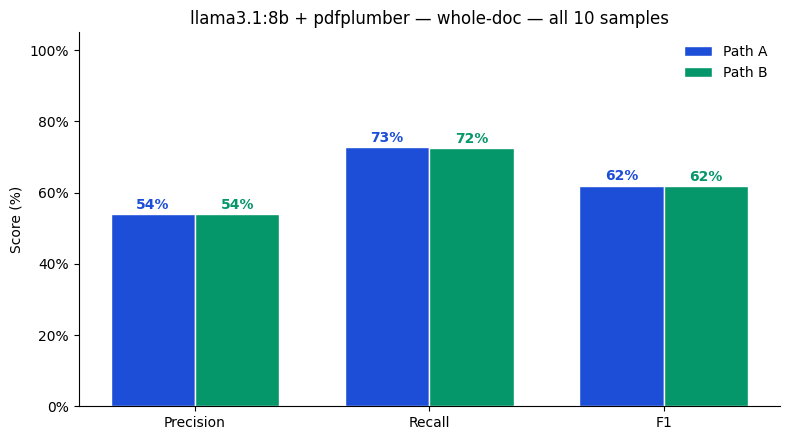

In [3]:
metrics = ["precision", "recall", "f1"]
labels  = ["Precision", "Recall", "F1"]
w = 0.36

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (path, color) in enumerate(zip(("A", "B"), (BLUE, GREEN))):
    vals = [summary.loc[path, m] for m in metrics]
    bars = ax.bar([x + (i - 0.5) * w for x in range(len(metrics))], vals, width=w,
                  label=f"Path {path}", color=color, edgecolor="white")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.5, f"{v:.0f}%",
                ha="center", fontsize=10, fontweight="bold", color=color)
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(labels)
ax.set_ylim(0, 105)
ax.set_ylabel("Score (%)")
ax.set_title(f"{MODEL} + pdfplumber — whole-doc — all 10 samples")
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
sns.despine()
plt.tight_layout()
plt.show()

---

## How the score is worked out

Before the detailed breakdowns, here is the whole scoring process on **one document**,
step by step. Change `SAMPLE` below to inspect a different one.

In short: the reference annotation and the model's output are each turned into a plain
list of items. The two lists are paired up. The counts of matched, mismatched and
left-over items become precision, recall and F1.


In [4]:
from dmpbridge.evaluation.evaluate import (
    extract_gold, _match_structured, _confusion_from_match,
    micro_prf1, resolve_old_gt_path,
)
from dmpbridge.core import paths

SAMPLE = 1          # <-- change this to look at another document

gold_items = extract_gold(resolve_old_gt_path(SAMPLE))
pred_items = extract_gold(paths.structured_path(TAG, SAMPLE))

print(f'Document: sample{SAMPLE}')
print(f'  reference annotation : {len(gold_items):>3} items')
print(f'  model output         : {len(pred_items):>3} items')


Document: sample1
  reference annotation :  28 items
  model output         :  32 items


### Step 1 — The reference annotation becomes a list

Every piece of text in your annotation, with the label you gave it.


In [5]:
print(f"{'#':>3}  {'label':<22}text")
print('-' * 96)
for i, (text, label) in enumerate(gold_items, 1):
    tail = '...' if len(text) > 64 else ''
    print(f'{i:>3}  {label:<22}{text[:64]}{tail}')


  #  label                 text
------------------------------------------------------------------------------------------------
  1  title                 DATA MANAGEMENT AND SHARING PLAN
  2  section.title         Element 1: Data Type:
  3  question.text         A. Types and amount of scientific data expected to be generated ...
  4  answer.text           This secondary data analysis project will analyze deidentified d...
  5  question.text         B. Scientific data that will be preserved and shared, and the ra...
  6  answer.text           As this is a secondary data analysis project, we will only be ab...
  7  question.text         C. Metadata, other relevant data, and associated documentation:
  8  answer.text           In addition to the data described above, code and models will be...
  9  section.title         Element 2: Related Tools, Software and/or Code:
 10  answer.text           Data will be analyzed with custom code by our statistical and co...
 11  section.title        

### Step 2 — The model's output becomes a list the same way

This is usually a *different length* from the reference — the model may split or
combine things differently.


In [6]:
print(f"{'#':>3}  {'label':<22}text")
print('-' * 96)
for i, (text, label) in enumerate(pred_items, 1):
    tail = '...' if len(text) > 64 else ''
    print(f'{i:>3}  {label:<22}{text[:64]}{tail}')


  #  label                 text
------------------------------------------------------------------------------------------------
  1  title                 DATA MANAGEMENT AND SHARING PLAN
  2  section.title         Element 1: Data Type:
  3  question.text         A. Types and amount of scientific data expected to be generated ...
  4  answer.text           This secondary data analysis project will analyze deidentified d...
  5  section.title         B. Scientific data that will be preserved and shared, and the ra...
  6  answer.text           As this is a secondary data analysis project, we will only be ab...
  7  question.text         about other studies.
  8  section.title         C. Metadata, other relevant data, and associated documentation:
  9  answer.text           In addition to the data described above, code and models will be...
 10  section.title         Element 2: Related Tools, Software and/or Code:
 11  answer.text           Data will be analyzed with custom code by our 

### Step 3 — Pair the two lists up

Each reference item looks for itself in the model's list, matching on shared words —
at least 75% of the words must overlap. Each model item can only be claimed once.

| Outcome | Meaning |
|---|---|
| **correct** | found, and given the right label |
| **wrong label** | found, but called something else |
| **missed** | the model produced nothing matching it |
| **extra** | the model produced something with no counterpart in the reference |


In [7]:
records, extras = _match_structured(paths.structured_path(TAG, SAMPLE), gold_items)

correct = [r for r in records if r['pred_label'] == r['gold_label']]
wrong   = [r for r in records if r['pred_label'] and r['pred_label'] != r['gold_label']]
missed  = [r for r in records if r['pred_label'] is None]

print(f'  correct      {len(correct):>3}')
print(f'  wrong label  {len(wrong):>3}')
print(f'  missed       {len(missed):>3}')
print('  ' + '-' * 16)
print(f'  reference    {len(gold_items):>3}   = correct + wrong + missed')
print()
print(f'  extra        {len(extras):>3}   produced with nothing to match')

if wrong:
    print()
    print('the wrong-label ones:')
    for r in wrong:
        print(f"    called {r['pred_label']:<20} should be {r['gold_label']:<20}"
              f"{r['gold_text'][:42]!r}")
if missed:
    print()
    print('the missed ones:')
    for r in missed:
        print(f"    {r['gold_label']:<22}{r['gold_text'][:56]!r}")
if extras:
    print()
    print('the extra ones:')
    for text, label in extras:
        print(f'    {label:<22}{text[:56]!r}')


  correct       19
  wrong label    9
  missed         0
  ----------------
  reference     28   = correct + wrong + missed

  extra          4   produced with nothing to match

the wrong-label ones:
    called section.title        should be question.text       'B. Scientific data that will be preserved '
    called section.title        should be question.text       'C. Metadata, other relevant data, and asso'
    called question.text        should be answer.text         'The following data will be created as a re'
    called section.title        should be question.text       'A. Repository where scientific data and me'
    called section.title        should be question.text       'B. How scientific data will be findable an'
    called section.title        should be question.text       'C. When and how long the scientific data w'
    called section.title        should be question.text       'A. Factors affecting subsequent access, di'
    called section.title        should be question.

### Step 4 — Turn the counts into a score

**Precision** — of everything the model produced, how much was right?

**Recall** — of everything in the reference, how much did it find?

**F1** — the two combined into a single number. It stays low unless *both* are high, so
a model cannot score well by producing very little (high precision, low recall) or by
producing everything it can think of (high recall, low precision).


In [8]:
n_correct   = len(correct)
n_produced  = len(correct) + len(wrong) + len(extras)
n_reference = len(gold_items)

precision = n_correct / n_produced
recall    = n_correct / n_reference
f1        = 2 * precision * recall / (precision + recall)

print(f'  precision = {n_correct} correct / {n_produced} produced     = {precision*100:.1f}%')
print(f'  recall    = {n_correct} correct / {n_reference} in reference = {recall*100:.1f}%')
print(f'  F1        = 2 x P x R / (P + R)            = {f1*100:.1f}%')

# Cross-check against the library, so this walkthrough cannot quietly drift from it.
lib = micro_prf1(_confusion_from_match(records, extras))
assert abs(lib['f1'] - f1) < 1e-9, 'walkthrough disagrees with the library'
print()
print(f"  the library computes the same F1: {lib['f1']*100:.1f}%")


  precision = 19 correct / 32 produced     = 59.4%
  recall    = 19 correct / 28 in reference = 67.9%
  F1        = 2 x P x R / (P + R)            = 63.3%

  the library computes the same F1: 63.3%


### Two things that surprise people

**A wrong label costs twice.** If the model finds the right text but calls it the wrong
thing, the reference item counts as *not found* **and** the model's version counts as
*something produced that shouldn't have been*. One mistake lowers both precision and
recall, which is why a handful of wrong labels moves F1 a long way.

**Counting mislabelled blocks by hand gives a different number**, and that is expected.
Scoring happens after `converter.to_structured()`, which glues consecutive blocks sharing
a label into one item. Five consecutive lines of one paragraph all mislabelled the same
way become a *single* wrong item — whereas five mislabelled `section.title` blocks stay
five separate items, because every section title starts a new section.

So block-level and item-level counts will not agree, and neither is wrong.


In [9]:
import json

blocks = json.loads(paths.labeled_path(TAG, SAMPLE).read_text(encoding='utf-8'))

print(f'  blocks the model labelled (stage 2) : {len(blocks):>3}')
print(f'  items actually scored     (stage 3) : {len(pred_items):>3}')
print(f'  reference items                     : {len(gold_items):>3}')
print()
print(f'  wrong-label + extra = {len(wrong)} + {len(extras)} = {len(wrong) + len(extras)} item-level mistakes')
print('  Compare a manual count of mistakes against this number, not the block count.')


  blocks the model labelled (stage 2) :  44
  items actually scored     (stage 3) :  32
  reference items                     :  28

  wrong-label + extra = 9 + 4 = 13 item-level mistakes
  Compare a manual count of mistakes against this number, not the block count.


## 2 — Per-label F1

Which of the five labels the model handles well. `gold items` is how many exist in the
reference data — a small count means the score is unstable.

label                       Path A    Path B   gold items
---------------------------------------------------------
title                        90.0%     90.0%           10
section.title                68.6%     68.6%           43
section.description          75.0%     75.0%            8
question.text                 4.2%      7.7%           18
answer.text                  72.6%     72.6%           55


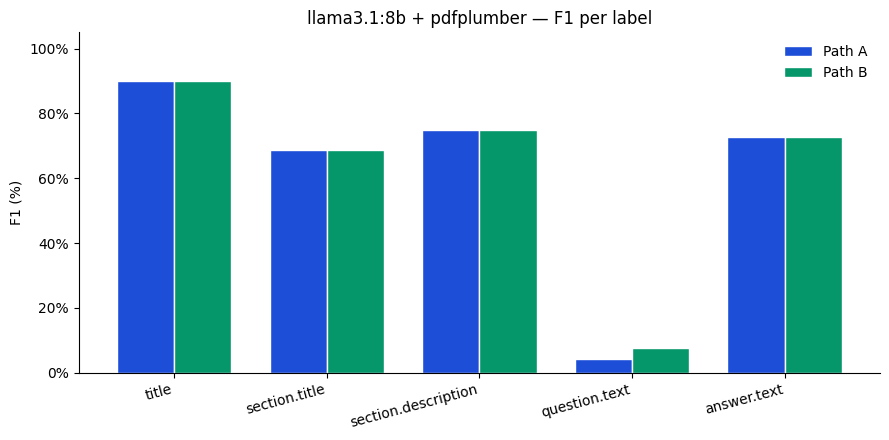

In [10]:
fa = compute_f1_rows(conf_a).set_index("label")
fb = compute_f1_rows(conf_b).set_index("label")
per_label = pd.DataFrame({"Path A": fa["f1"] * 100, "Path B": fb["f1"] * 100})

print(f"{'label':<24}{'Path A':>10}{'Path B':>10}{'gold items':>13}")
print('-' * 57)
for lab, row in per_label.iterrows():
    print(f"{lab:<24}{row['Path A']:>9.1f}%{row['Path B']:>9.1f}%{fb.loc[lab, 'support']:>13}")

ax = per_label.plot(kind="bar", figsize=(9, 4.5), width=0.75,
                    color=[BLUE, GREEN], edgecolor="white")
ax.set_ylabel("F1 (%)")
ax.set_xlabel("")
ax.set_ylim(0, 105)
ax.set_title(f"{MODEL} + pdfplumber — F1 per label")
ax.legend(frameon=False)
plt.xticks(rotation=15, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
sns.despine()
plt.tight_layout()
plt.show()

## 3 — Per-sample accuracy

Which documents the model handles and which it struggles with.

sample     correct  total   accuracy
------------------------------------
1               19     28      67.9%
2               16     25      64.0%
3               11     14      78.6%
4                3      3     100.0%
5                9     13      69.2%
6                6     11      54.5%
7                1      3      33.3%
8               12     13      92.3%
9                8     11      72.7%
10              12     13      92.3%
------------------------------------
TOTAL           97    134      72.4%


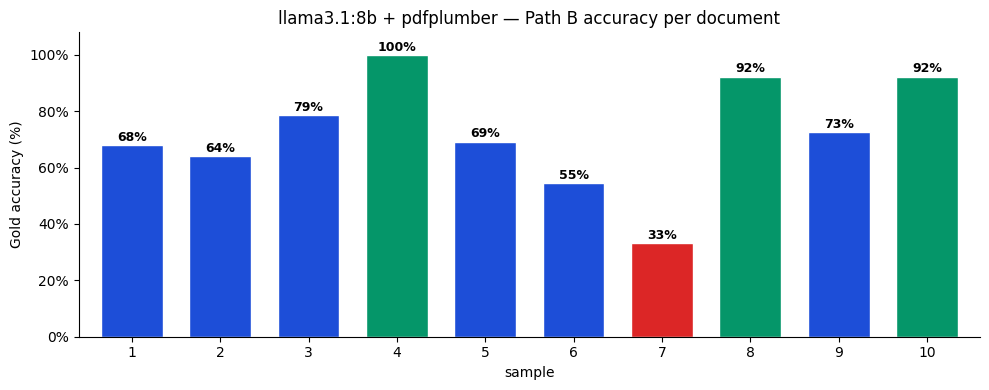

In [11]:
ps = df_b.set_index("sample").copy()
ps.index = [s.replace("sample", "") for s in ps.index]
ps = ps.loc[sorted(ps.index, key=int)]

print(f"{'sample':<9}{'correct':>9}{'total':>7}{'accuracy':>11}")
print('-' * 36)
for s, r in ps.iterrows():
    print(f"{s:<9}{r['correct']:>9.0f}{r['total']:>7.0f}{r['accuracy'] * 100:>10.1f}%")
print('-' * 36)
print(f"{'TOTAL':<9}{ps['correct'].sum():>9.0f}{ps['total'].sum():>7.0f}"
      f"{ps['correct'].sum() / ps['total'].sum() * 100:>10.1f}%")

colors = ["#dc2626" if v < 0.5 else GREEN if v >= 0.8 else BLUE for v in ps["accuracy"]]
ax = (ps["accuracy"] * 100).plot(kind="bar", figsize=(10, 4), color=colors,
                                 width=0.7, edgecolor="white")
for i, v in enumerate(ps["accuracy"] * 100):
    ax.text(i, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("Gold accuracy (%)")
ax.set_xlabel("sample")
ax.set_ylim(0, 108)
ax.set_title(f"{MODEL} + pdfplumber — Path B accuracy per document")
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
sns.despine()
plt.tight_layout()
plt.show()

## 4 — Confusion matrix

Rows are the true label, columns what the model predicted. The diagonal is correct;
`missed` counts reference items the model produced nothing for.

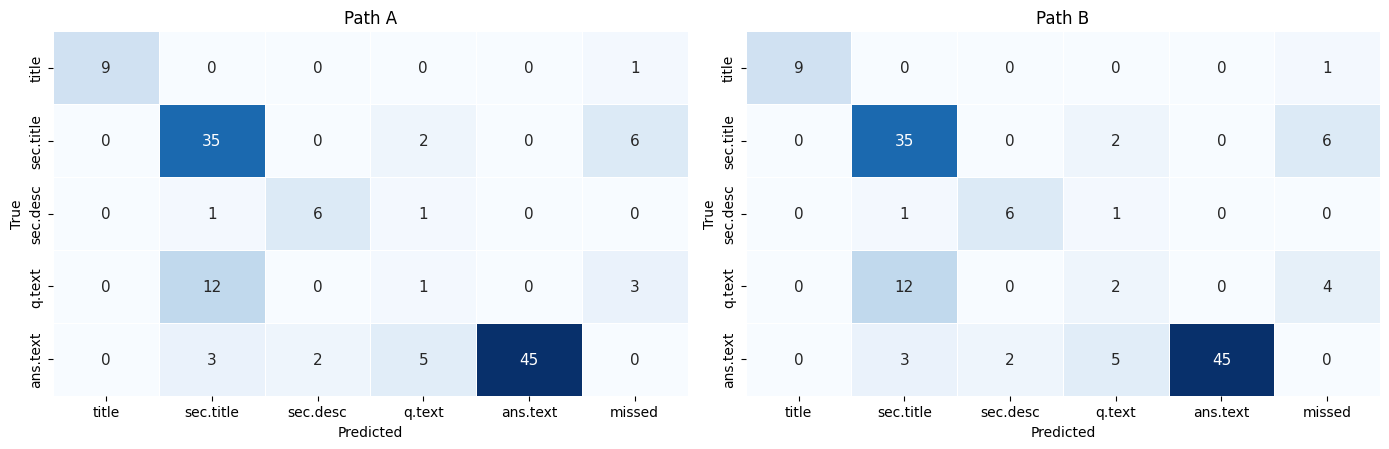

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, (path, conf) in zip(axes, (("A", conf_a), ("B", conf_b))):
    sns.heatmap(confusion_matrix_df(conf), annot=True, fmt="d", cmap="Blues",
                linewidths=0.5, linecolor="white", ax=ax, cbar=False,
                annot_kws={"size": 11})
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Path {path}")
plt.tight_layout()
plt.show()

## 5 — Where it goes wrong

The most common confusions, with example text.

In [13]:
print(f"Path B — {len(err_b)} error(s)\n")
counts = err_b.groupby(["true", "pred"]).size().sort_values(ascending=False)
print(f"{'true label':<24}{'predicted as':<24}{'count':>6}")
print('-' * 54)
for (t, p), c in counts.head(10).items():
    print(f"{t:<24}{p:<24}{c:>6}")
print("\n'no_gold_match' means the model produced an item with no counterpart in the reference.")

print("\nExamples:")
for _, e in err_b.head(8).iterrows():
    print(f"  [{e['sample']}]  {e['true']} -> {e['pred']}")
    print(f"      {e['text'][:100]!r}")

Path B — 83 error(s)

true label              predicted as             count
------------------------------------------------------
no_gold_match           answer.text                 24
no_gold_match           question.text               24
question.text           section.title               12
no_gold_match           section.title                8
answer.text             question.text                5
answer.text             section.title                3
answer.text             section.description          2
section.title           question.text                2
no_gold_match           title                        1
section.description     question.text                1

'no_gold_match' means the model produced an item with no counterpart in the reference.

Examples:
  [sample1]  question.text -> section.title
      'B. Scientific data that will be preserved and shared, and the rationale for doing so:'
  [sample1]  question.text -> section.title
      'C. Metadata, other relevant da

## 6 — What the annotation rules actually do

Path B applies `data/input/Rules.xlsx` to the structured output before scoring.
The table was rewritten on 6 August, so it is worth seeing which of its 16 rows
fire on real data and what each one changes.

In [14]:
import json
from collections import Counter
from dmpbridge.evaluation.annotation_rules import _RULES, _state, RULE_FIELDS
from dmpbridge.core import paths

ROWNO = {k: i + 1 for i, k in enumerate(_RULES)}
fired, effect = Counter(), Counter()

for n in range(1, 11):
    p = paths.structured_path(TAG, n)
    if not p.exists():
        continue
    t = json.loads(p.read_text(encoding='utf-8'))['narrative']['template']
    for s in t.get('section', []):
        for q in s.get('question', []):
            vals = {'title': t.get('title'),
                    'section.title': s.get('title'),
                    'section.description': s.get('description'),
                    'question.text': q.get('text')}
            key = tuple(_state(vals[f]) for f in RULE_FIELDS)
            fired[key] += 1
            action = _RULES[key]
            if action is None:
                effect['question already had text - left alone'] += 1
            else:
                effect[f'filled from {action[0]}'] += 1

print('Rows that fire on this run:')
print()
hdr = '/'.join(f.replace('section.', 'sec.').replace('question.text', 'q.text')
               for f in RULE_FIELDS)
print(f"{'row':>4}  {hdr:<40}{'action':<42}{'count':>6}")
print('-' * 94)
for k, v in _RULES.items():
    if not fired.get(k):
        continue
    act = 'leave unchanged' if v is None else f'{v[0]} -> {v[1]}'
    print(f"{ROWNO[k]:>4}  {'/'.join(k):<30}{act:<42}{fired[k]:>6}")

print()
print('What those actions do:')
print()
for k, v in effect.most_common():
    print(f'  {k:<44}{v:>4}')
print(f"  {'':<44}{'---':>4}")
print(f"  {'total questions':<44}{sum(effect.values()):>4}")

Rows that fire on this run:

 row  title/sec.title/sec.description/q.text  action                                     count
----------------------------------------------------------------------------------------------
   9  N/E/E/E                       title -> question.text                         2
  10  N/E/E/N                       leave unchanged                                1
  13  N/N/E/E                       section.title -> question.text                37
  14  N/N/E/N                       leave unchanged                               23
  15  N/N/N/E                       section.title -> question.text                 5
  16  N/N/N/N                       leave unchanged                                8

What those actions do:

  filled from section.title                     42
  question already had text - left alone        32
  filled from title                              2
                                               ---
  total questions                         

### Path A vs Path B

The two paths now score almost identically (61.7% vs 61.6%). That is expected given
what the rules do here: of 78 questions, 45 are filled — 43 from `section.title` and 2
from the document title — and `extract_gold()` deliberately drops a `question.text` that
equals its section title, to avoid counting the same text twice. So most of what the
rules add is not counted as a separate item, and the two paths converge.

The visible difference is confined to `question.text`: 4.1% on Path A against 7.5% on
Path B. Both are poor, on 18 gold items.

> **On earlier figures in this notebook's history.** A run this morning showed Path B at
> 69.2% against Path A at 63.0%. That was produced by a misread of `Rules.xlsx` — the
> sheet's column order had changed, placing `question.text` in column 4 rather than
> column 2, and the rules were transcribed against the old order. The resulting table
> overwrote and cleared question text rather than filling it. Those numbers describe a
> rule set that was never intended and should be disregarded.

With the corrected column order the rules reproduce the new-version reference annotation
**exactly on all 10 documents**, including sample 5 — which had previously been treated
as needing an unimplemented sub-question merge. That merge turns out not to be required.

## Notes

- Repeated identical runs of this pipeline have varied by roughly **3 points of F1**, so
  differences smaller than that should not be read as real.
- Sample 5 will always show errors under Path B: its reference annotation merges several
  sub-questions into one with their answers joined, and no rule in `Rules.xlsx` covers merging.
- This is 1 of the 9 planned configurations (E01–E09). No other model or extractor has been
  run under the current pipeline.